# Lab 2.6 — Whose fault was it? Causality by segment, with a competitor in the room

You raised your margin last summer. Volume went **up**. Does that mean higher
prices attract customers? Of course not — the competitor got expensive at the
same time, and it was peak season. Three things moved at once, and the till
only records the total.

**Causal inference is the craft of untangling that.** This notebook teaches it
the track's way: plain English, small numbers, and a toy world where we *know*
the right answer, so we can catch every method that lies.

Four words, defined before use (rule of the track):

- **Causal effect** — what would happen to volume *because* you moved your
  margin, holding everything else still. Not "what happened next".
- **Confounder** — anything that pushes on *both* your price and your demand
  at the same time (season, the competitor, a manager's habits). Confounders
  are why "price up, volume up" can appear in the data while the true effect
  is "price up, volume down".
- **Segment** — a group of customers who behave alike ([file 4.1](../04_satisfy_the_regulator/01_segments_and_fairness.md)). Airport
  travellers and online shoppers do not share an elasticity, so one blended
  number misleads you about both.
- **Cross-price effect** — how *their* price moves *your* volume. In a
  competitive market it is often as big as your own-price effect.

**The plan (run top to bottom, ~20 minutes):**

1. Build a toy travel-money world where we set the true sensitivities.
2. Try the naive approach — fit volume against price. Watch it fail.
3. Fix it by controlling for the confounders. Recover the truth, per segment.
4. See the same fix as *residual-on-residual* — the trick that scales into
   Double ML ([N10](../05_the_panel/N10_heterogeneous_elasticity_dml.ipynb)).
5. Treat the competitor properly: confounder *and* second steering wheel.
6. Run the gold standard — a small randomised experiment — and compare.

[File 2.2](02_tests_and_experiments.md) taught you that before/after comparisons lie. Today's upgrade:
**even a regression lies, unless every reason you changed price is in it.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# Chart style: colour-blind-safe palette in fixed order, quiet grid, thin marks
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
INK, SUB, MUT, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": AXIS, "axes.labelcolor": SUB, "axes.titlecolor": INK,
    "xtick.color": MUT, "ytick.color": MUT,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 11, "axes.titlesize": 12,
    "figure.figsize": (8, 4.2), "figure.dpi": 110, "legend.frameon": False,
})
def tidy(ax):          # y-gridlines only — the grid should whisper
    ax.grid(axis="x", visible=False)

## Step 1 — a toy world where we know the right answer

Think of a flight simulator: we build a world, *we* set the physics, then we
test which measurement methods land the plane. Any method that can't recover
numbers we chose ourselves cannot be trusted on real data.

Our travel-money desk sells euros through three segments. Price is quoted as
**margin in percentage points** ([file 1.2](../01_set_the_rate/02_percentages_and_basis_points.md)): margin 2.0 means we keep 2% of the
order value. The true sensitivities we are hiding in the data:

| Segment | Own-margin effect (per +1pp) | Competitor effect (per +1pp of *their* margin) | Story |
|---|---|---|---|
| Airport | volume −26% (β = −0.3) | +11% (γ = +0.1) | captive, in a hurry |
| High Street | volume −55% (β = −0.8) | +65% (γ = +0.5) | will walk two doors down |
| Online | volume −78% (β = −1.5) | +230% (γ = +1.2) | one click from a comparison site |

(Effects are in log-points: volume multiplies by e^β. For small moves,
log-points ≈ percent — a +0.2pp margin rise costs the Airport segment about
0.3 × 0.2 = 6% of volume.)

**And here is the trap we are planting.** Our pricing desk follows a very
human rule:

> margin = 0.8 + 0.5 × competitor's margin + 0.3 extra in peak season (+ noise)

So we price high exactly when demand is naturally strong — when the
competitor is expensive and when it's summer. Both are **confounders**: they
push our price up *and* our volume up. Two years of daily data, three
segments, trap set.

In [2]:
SEGMENTS = ["Airport", "High Street", "Online"]
BETA  = {"Airport": -0.3, "High Street": -0.8, "Online": -1.5}   # own-margin effect
GAMMA = {"Airport":  0.1, "High Street":  0.5, "Online":  1.2}   # competitor effect
BASE  = {"Airport":  5.0, "High Street":  6.0, "Online":  6.5}   # size of segment
PEAK_LIFT = 0.4                                                  # summer demand boost

days = pd.date_range("2024-01-01", periods=730, freq="D")
peak = days.month.isin([6, 7, 8]).astype(float)                  # peak season flag

comp_m = np.clip(1.7 + 0.4*np.sin(2*np.pi*np.arange(730)/365)    # competitor wanders
                 + rng.normal(0, 0.15, 730), 1.0, 2.6)
our_m  = 0.8 + 0.5*comp_m + 0.3*peak + rng.normal(0, 0.12, 730)  # the desk's rule!

rows = []
for s in SEGMENTS:
    log_q = (BASE[s] + BETA[s]*our_m + GAMMA[s]*comp_m
             + PEAK_LIFT*peak + rng.normal(0, 0.15, 730))
    rows.append(pd.DataFrame({"date": days, "segment": s, "margin": our_m,
                              "comp_margin": comp_m, "peak": peak,
                              "volume": np.exp(log_q)}))
df = pd.concat(rows, ignore_index=True)
df["log_volume"] = np.log(df["volume"])
df.sample(5, random_state=1).round({"margin": 2, "comp_margin": 2, "volume": 1, "log_volume": 2})

,date,segment,margin,comp_margin,peak,volume,log_volume
353,2024-12-19,Airport,1.61,1.59,0.0,101.5,4.62
1631,2024-06-20,Online,2.30,1.85,1.0,281.9,5.64
414,2025-02-18,Airport,1.90,1.95,0.0,117.3,4.76
1827,2025-01-02,Online,1.80,1.50,0.0,234.0,5.46
851,2024-05-01,High Street,1.71,1.96,0.0,158.0,5.06


## Step 2 — the naive answer, and why it lies

The obvious move: for each segment, plot volume against our margin and fit a
line. The slope should be the price effect… shouldn't it?

Watch what actually comes out. Remember the truths: −0.3, −0.8, −1.5.

In [3]:
def ols(X, y):
    "Ordinary least squares with standard errors. Returns (coefs, ses); coefs[0] is the intercept."
    X1 = np.column_stack([np.ones(len(y)), X])
    coef, *_ = np.linalg.lstsq(X1, y, rcond=None)
    resid = y - X1 @ coef
    sigma2 = resid @ resid / (len(y) - X1.shape[1])
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X1.T @ X1)))
    return coef, se

naive = {}
for s in SEGMENTS:
    d = df[df.segment == s]
    coef, se = ols(d[["margin"]].to_numpy(), d.log_volume.to_numpy())
    naive[s] = (coef[1], se[1])

print(f"{'segment':<12} {'truth':>7} {'naive estimate':>15}")
for s in SEGMENTS:
    print(f"{s:<12} {BETA[s]:>7.2f} {naive[s][0]:>10.2f} ± {1.96*naive[s][1]:.2f}")

segment        truth  naive estimate
Airport        -0.30       0.15 ± 0.06
High Street    -0.80      -0.04 ± 0.06
Online         -1.50      -0.22 ± 0.09


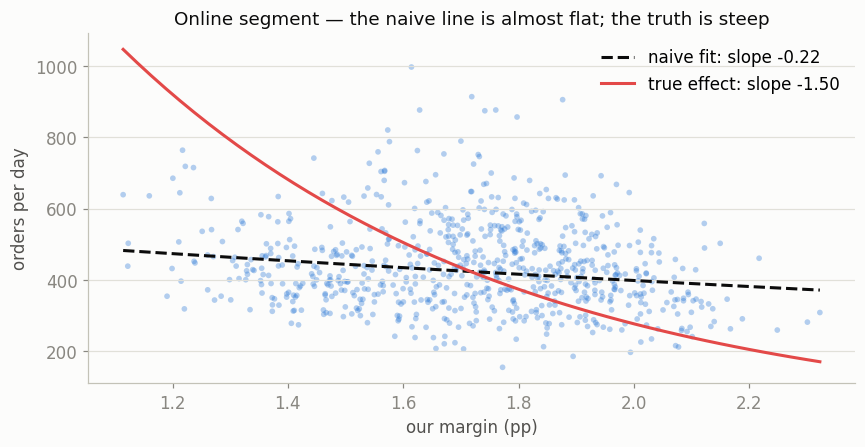

Why: high-margin days were mostly summer days with an expensive competitor —
days when volume was going to be high anyway. The two forces cancel in the plot.


In [4]:
# The picture behind the failure — Online, the most price-sensitive segment
d = df[df.segment == "Online"]
coef, _ = ols(d[["margin"]].to_numpy(), d.log_volume.to_numpy())
mg = np.linspace(d.margin.min(), d.margin.max(), 50)

fig, ax = plt.subplots()
ax.scatter(d.margin, d.volume, s=14, alpha=0.35, color=C[0], edgecolors="none")
ax.plot(mg, np.exp(coef[0] + coef[1]*mg), color=INK, linestyle="--",
        label=f"naive fit: slope {coef[1]:+.2f}")
a_true = d.log_volume.mean() - BETA["Online"] * d.margin.mean()   # anchor through the cloud's centre
ax.plot(mg, np.exp(a_true + BETA["Online"]*mg),
        color=C[5], label=f"true effect: slope {BETA['Online']:+.2f}")
ax.set_xlabel("our margin (pp)"); ax.set_ylabel("orders per day")
ax.set_title("Online segment — the naive line is almost flat; the truth is steep")
ax.legend(); tidy(ax); plt.tight_layout(); plt.show()

print("Why: high-margin days were mostly summer days with an expensive competitor —")
print("days when volume was going to be high anyway. The two forces cancel in the plot.")

**Read that table again.** For the Airport segment the naive method says the
effect is *positive* — raise margins, get more customers. If you took that to
a pricing committee and they believed it, you would ratchet prices up every
quarter and blame the weather when volume finally collapsed.

The naive line is not measuring your price effect. It is measuring
*your desk's pricing rule* — high margins happen on good days, so high
margins "look" harmless. This is the same lie as [file 2.2](02_tests_and_experiments.md)'s before/after
comparison, wearing a regression costume.

## Step 3 — control for whatever caused the price

The fix is almost disappointingly simple. The desk's rule used two inputs:
the competitor's margin and the season. Put **both of them into the
regression next to our margin**, and the regression compares like with like —
days where the competitor and the season were the same and only *our* margin
differed. Statisticians call this *adjusting for confounders*; you can call
it "compare fair days".

One honest warning before we celebrate: this only works for confounders you
**measured**. If the desk also raised margins whenever a cruise ship docked,
and no one logged cruise ships, that bias stays in. That is why Step 6
(the experiment) exists.

In [5]:
adjusted = {}
for s in SEGMENTS:
    d = df[df.segment == s]
    X = d[["margin", "comp_margin", "peak"]].to_numpy()
    coef, se = ols(X, d.log_volume.to_numpy())
    adjusted[s] = (coef[1], se[1])          # coefficient on our margin

summary = pd.DataFrame({
    "truth":    [BETA[s] for s in SEGMENTS],
    "naive":    [naive[s][0] for s in SEGMENTS],
    "adjusted": [adjusted[s][0] for s in SEGMENTS],
}, index=SEGMENTS).round(2)
summary

,truth,naive,adjusted
Airport,-0.3,0.15,-0.29
High Street,-0.8,-0.04,-0.83
Online,-1.5,-0.22,-1.54


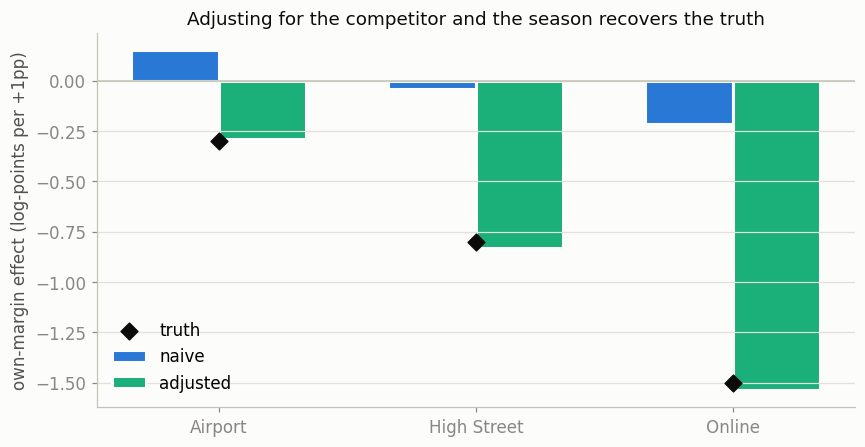

In [6]:
x = np.arange(len(SEGMENTS)); w = 0.34
fig, ax = plt.subplots()
ax.bar(x - w/2, [naive[s][0] for s in SEGMENTS], w, label="naive",
       color=C[0], edgecolor="#fcfcfb", linewidth=2)
ax.bar(x + w/2, [adjusted[s][0] for s in SEGMENTS], w, label="adjusted",
       color=C[1], edgecolor="#fcfcfb", linewidth=2)
ax.scatter(x, [BETA[s] for s in SEGMENTS], marker="D", s=60, color=INK,
           zorder=3, label="truth")
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_xticks(x, SEGMENTS); ax.set_ylabel("own-margin effect (log-points per +1pp)")
ax.set_title("Adjusting for the competitor and the season recovers the truth")
ax.legend(); tidy(ax); plt.tight_layout(); plt.show()

Three segments, three different elasticities, all recovered — from the same
observational data that just lied to us. Nothing changed except that we told
the regression *why* prices moved.

**The rule to memorise:** a regression slope is causal only if every reason
you changed price is sitting in the regression beside it. Ask "what did the
desk look at when it set this price?" — that list *is* your confounder list.

## Step 4 — the same fix, seen through a sharper lens: residual-on-residual

Here is a beautiful fact (the Frisch–Waugh–Lovell theorem, but the idea is
simple). The adjusted slope from Step 3 can be produced in three little
steps:

1. Predict **our margin** from the confounders. Keep the leftovers
   (residuals) — the part of pricing the confounders *can't* explain: the
   desk's free choices, its noise, its whims.
2. Predict **volume** from the confounders. Keep the leftovers — demand
   swings the confounders can't explain.
3. Fit a line through leftovers vs leftovers. That slope **is** the causal
   effect.

Why care, if it gives the same number? Because steps 1 and 2 don't have to
be straight lines. Replace them with gradient boosting over hundreds of
messy confounders and the recipe still works — that is **Double Machine
Learning**, exactly what [N10](../05_the_panel/N10_heterogeneous_elasticity_dml.ipynb)
does at production scale. What you are running below is DML with training
wheels.

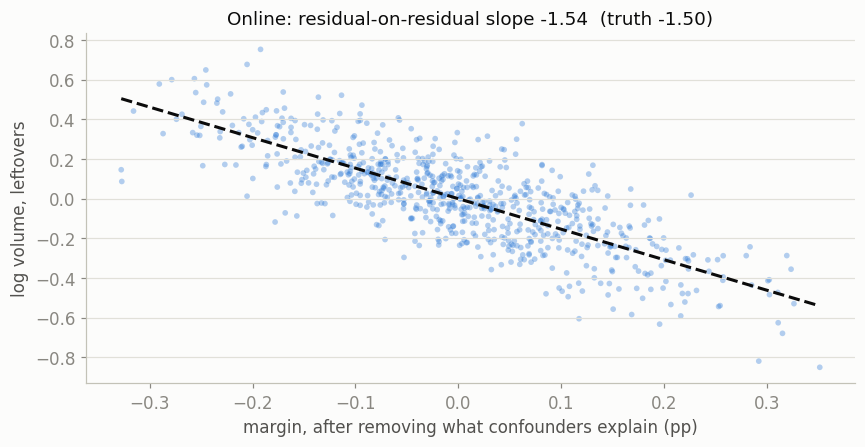

This cloud is the closest thing observational data has to a free experiment:
price variation with no confounder fingerprints left on it.


In [7]:
d = df[df.segment == "Online"]
Z = d[["comp_margin", "peak"]].to_numpy()

cz, _ = ols(Z, d.margin.to_numpy())          # step 1: margin explained by confounders
m_left = d.margin.to_numpy() - np.column_stack([np.ones(len(d)), Z]) @ cz

cq, _ = ols(Z, d.log_volume.to_numpy())      # step 2: volume explained by confounders
q_left = d.log_volume.to_numpy() - np.column_stack([np.ones(len(d)), Z]) @ cq

slope, se = ols(m_left[:, None], q_left)     # step 3: leftovers vs leftovers

fig, ax = plt.subplots()
ax.scatter(m_left, q_left, s=14, alpha=0.35, color=C[0], edgecolors="none")
mg = np.linspace(m_left.min(), m_left.max(), 20)
ax.plot(mg, slope[0] + slope[1]*mg, color=INK, linestyle="--")
ax.set_xlabel("margin, after removing what confounders explain (pp)")
ax.set_ylabel("log volume, leftovers")
ax.set_title(f"Online: residual-on-residual slope {slope[1]:+.2f}  (truth {BETA['Online']:+.2f})")
tidy(ax); plt.tight_layout(); plt.show()

print("This cloud is the closest thing observational data has to a free experiment:")
print("price variation with no confounder fingerprints left on it.")

## Step 5 — the competitor is a second steering wheel

Notice the competitor played **two roles** in this notebook, and you must
keep them straight:

1. **Confounder.** Our desk reacts to their price. Any elasticity estimated
   without their price in the model is contaminated — that was Step 2's lie.
2. **Lever that isn't yours.** Their margin moves your volume directly
   (γ). When they cut 0.5pp, your Online volume drops ~45% *with your price
   untouched*. If you don't model this, you will blame your own pricing —
   or worse, credit it.

The decision consequence: in competitive segments what matters is the
**price gap**, not your price alone. Below, the response curves from the
*fitted* Step-3 models (in real life you never get to peek at the truth) —
volume indexed to 100 at margin 2.0, competitor held at 1.8.

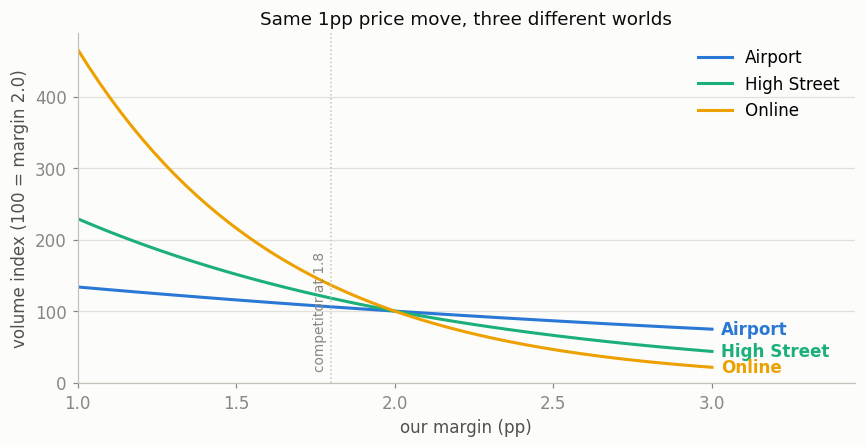

In [8]:
mg = np.linspace(1.0, 3.0, 60)
fig, ax = plt.subplots()
for i, s in enumerate(SEGMENTS):
    q = 100 * np.exp(adjusted[s][0] * (mg - 2.0))    # fitted own-margin effect
    ax.plot(mg, q, color=C[i], label=s)
    ax.annotate(s, (mg[-1], q[-1]), xytext=(6, 0), textcoords="offset points",
                color=C[i], fontweight="bold", va="center")
ax.axvline(1.8, color=AXIS, linewidth=1, linestyle=":")
ax.annotate("competitor at 1.8", (1.8, 20), color=MUT, rotation=90,
            xytext=(-12, 0), textcoords="offset points", fontsize=9)
ax.set_xlim(1.0, 3.45); ax.set_xlabel("our margin (pp)")
ax.set_ylabel("volume index (100 = margin 2.0)")
ax.set_title("Same 1pp price move, three different worlds")
ax.legend(loc="upper right"); tidy(ax); plt.tight_layout(); plt.show()

**How to read it like a pricing manager:** above the competitor's 1.8, the
Online curve falls off a cliff — every basis point of gap is punished. The
Airport curve barely notices; those customers aren't comparing. So the same
headline decision ("raise margins 0.3pp") is nearly free at the airport and
ruinous online. Segment-level causality is not a statistical nicety — it is
the difference between one good decision and one bad one wearing an average.

And one warning from [file 1.5](../01_set_the_rate/05_competition.md): their price is a lever *they* control. If you
cut to widen the gap, they can cut back — the game in
[N8](../05_the_panel/N8_competitor_response_game.ipynb). Estimating γ tells you
your exposure; it does not promise they'll sit still.

## Step 6 — the gold standard: a small randomised experiment

Step 3 handled the confounders we *measured*. Randomisation handles the ones
we didn't — measured or not, known or unknown — because a coin flip is
correlated with nothing.

Design (straight from [file 2.2](02_tests_and_experiments.md)): take 200 High Street branches, randomly give
100 of them a **+0.25pp** margin for four weeks, leave 100 alone, and compare
log-volumes. Nobody peeks, the metric is chosen in advance.

In [9]:
n = 200; lift = 0.25
treated = np.zeros(n, dtype=bool); treated[rng.permutation(n)[:100]] = True
m_branch = np.where(treated, 1.9 + lift, 1.9)

# Each branch's 4-week volume follows the same hidden physics (β = −0.8) + noise
log_v = 3.3 + BETA["High Street"] * m_branch + rng.normal(0, 0.12, n)

diff = log_v[treated].mean() - log_v[~treated].mean()
se_d = np.sqrt(log_v[treated].var(ddof=1)/100 + log_v[~treated].var(ddof=1)/100)
exp_est, exp_se = diff/lift, se_d/lift

print(f"experiment estimate: {exp_est:+.2f} ± {1.96*exp_se:.2f}   (truth {BETA['High Street']:+.2f})")

experiment estimate: -0.76 ± 0.13   (truth -0.80)


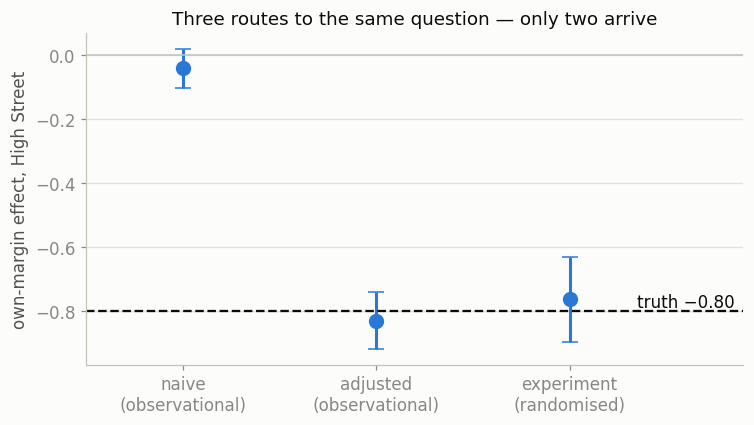

In [10]:
methods = ["naive\n(observational)", "adjusted\n(observational)", "experiment\n(randomised)"]
est = [naive["High Street"][0], adjusted["High Street"][0], exp_est]
ci  = [1.96*naive["High Street"][1], 1.96*adjusted["High Street"][1], 1.96*exp_se]

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(range(3), est, yerr=ci, fmt="o", color=C[0], markersize=9,
            capsize=5, linewidth=2)
ax.axhline(BETA["High Street"], color=INK, linestyle="--", linewidth=1.5)
ax.annotate("truth −0.80", (2.35, BETA["High Street"]), color=INK, va="bottom")
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_xticks(range(3), methods); ax.set_xlim(-0.5, 2.9)
ax.set_ylabel("own-margin effect, High Street")
ax.set_title("Three routes to the same question — only two arrive")
tidy(ax); plt.tight_layout(); plt.show()

The adjusted estimate and the experiment agree — which is exactly the check
you run in real life. **When they agree**, you can trust the observational
model where you can't experiment (you can't randomise the competitor, or
Christmas). **When they disagree**, the experiment wins, and the gap tells
you a confounder is missing from your model. Experiments are how models earn
the right to be believed.

## The 60-second summary (say it out loud)

> "Our desk prices off the competitor and the season, so raw price–volume
> data is confounded — naively fitted, Airport elasticity even comes out
> positive. I adjust for what drove the price — competitor margin and
> season — which is residual-on-residual under the hood, the same recipe
> DML scales up. I estimate it *per segment*, because Airport (−0.3) and
> Online (−1.5) are different businesses, and I keep the competitor's price
> in the model both as confounder and as a direct driver of demand. Then I
> validate the whole thing with a small randomised branch test. Model and
> experiment agree, so I trust the model between experiments."

## Where this goes in the repo — the ladder

| Rung | Where | What gets added |
|---|---|---|
| Elasticity as one number | file [1.3](../01_set_the_rate/03_elasticity.md) | the concept itself |
| Different prices, different people | file [4.1](../04_satisfy_the_regulator/01_segments_and_fairness.md) | segments and fairness |
| Proper test design | file [2.2](02_tests_and_experiments.md) | control groups, MDE |
| Thousands of thin segments | [N2](../05_the_panel/N2_hierarchical_elasticity.ipynb) | segments borrow strength from each other |
| Confounders too many/nonlinear for OLS | [N10](../05_the_panel/N10_heterogeneous_elasticity_dml.ipynb) | ML in steps 1–2 of residual-on-residual = DML |
| The competitor moves back | [N8](../05_the_panel/N8_competitor_response_game.ipynb) | game theory, matched controls |

## Practice (try before peeking)

1. The naive Airport slope came out **positive**. A colleague says "see,
   premium pricing signals quality — customers like it." What do you say?
2. The competitor cuts their margin by 0.5pp everywhere. Using the fitted γ
   values (+0.1 / +0.5 / +1.2), roughly how much volume does each segment
   lose if you do nothing — and where would you consider responding?
3. Your adjusted model and a branch experiment *disagree* by a lot. Which do
   you believe, and what does the gap itself tell you?

<details><summary>Answers</summary>

1. The desk raised margins on days demand was strong anyway (summer,
   expensive competitor). The positive slope measures the desk's *rule*, not
   customer psychology. Adjusted for those two drivers, the slope is −0.3.
2. Volume multiplies by e^(−γ×0.5): Airport ≈ −5%, High Street ≈ −22%,
   Online ≈ −45%. Respond (if at all) online first, hold the airport —
   and remember [file 1.5](../01_set_the_rate/05_competition.md) before matching anyone.
3. The experiment — randomisation needs no confounder list. The gap is a
   measurement of *how much confounding your model still misses*; go hunt
   for what the desk knew that your data didn't record.

</details>